# Lattice-gas Monte Carlo with configurable interactions
`latticegas.LatticeGas` describes classical particles that either occupy a site or do not,
adsorbates on a surface, vacancies in a crystal or any classical binary order, with occupations
$n_i\in\{0,1\}$ and the energy

$$
E = \sum_{i,j} J_{ij}\,n_i n_j + \sum_i \mu_i n_i
$$

where the sum runs over both orderings of every pair, so that each bond enters twice, and a
positive $J_{ij}$ is a repulsion. `lg.add_interaction(Jij=[J1,J2,...])` adds couplings to
first, second and further neighbors, `lg.add_tensor(fun)` any other real-space coupling, and
`lg.mu` holds the onsite energy of every site, so that the chemical potential enters as
`lg.mu = -mu`. Two Monte Carlo ensembles are available. `lg.optimize_energy()` swaps the
occupations of pairs of sites with the Metropolis rule, which keeps the number of particles
fixed at the filling given to the constructor, and `lg.anneal()` runs it through a decreasing
temperature schedule, a simulated anneal, keeping the best configuration found.
`lg.optimize_grand_canonical()` instead flips single occupations, so that the filling itself
fluctuates under the chemical potential, which is the way to scan a phase diagram.
### Import the necessary libraries

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
from pyqula import supercell
from pyqula import latticegas
np.random.seed(4) # reproducible Monte Carlo runs

### Ordered arrangements found by simulated annealing
On the triangular lattice the arrangement the particles choose depends on the range of the
repulsion. With a first-neighbor repulsion at a third filling, every particle can avoid its
first neighbors by occupying one of three sublattices, the $\sqrt3\times\sqrt3$ structure;
adding a second-neighbor repulsion at a quarter filling pushes the particles to third
neighbors, the $2\times2$ structure. The maps are the occupations after the anneal, and the
local energy of every site, which is zero wherever the arrangement is perfect and marks the
defects that remain, where two particles sit too close. The right panel is the energy along
each anneal.

Final energy per site: 0.0625


Final energy per site: 0.08333333333333333


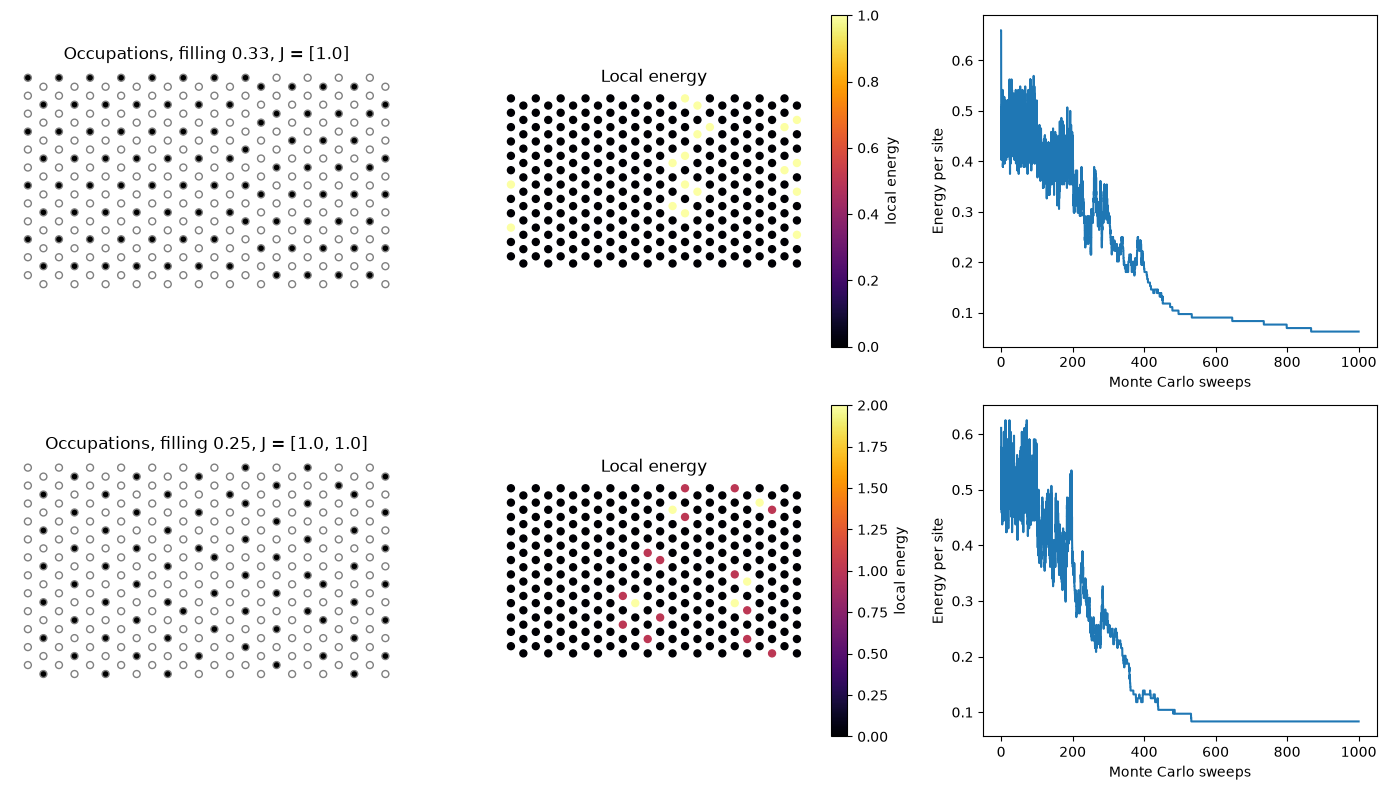

In [2]:
g = geometry.triangular_lattice()
g = supercell.turn_orthorhombic(g) # rectangular cell
g = g.get_supercell(12) # periodic supercell, compatible with both orders

cases = [(1./3.,[1.]),(1./4.,[1.,1.])] # (filling, repulsion per neighbor shell)
fig,axs = plt.subplots(2,3,figsize=(14,8))
for ax,(filling,Jij) in zip(axs,cases):
    lg = latticegas.LatticeGas(g,filling=filling) # random occupations at this filling
    lg.add_interaction(Jij=Jij) # repulsion between neighbors
    es = lg.anneal(temps=np.geomspace(2.,0.05,10),ntries=100*lg.nsites) # simulated annealing
    sc = ax[0].scatter(g.x,g.y,c=lg.den,cmap="Greys",vmin=0,vmax=1,s=25,edgecolors="gray")
    ax[0].set_title(f"Occupations, filling {filling:.2f}, J = {Jij}")
    sc = ax[1].scatter(g.x,g.y,c=lg.get_local_energy(),cmap="inferno",s=25)
    plt.colorbar(sc,ax=ax[1],label="local energy")
    ax[1].set_title("Local energy")
    for a in ax[:2]: a.set_aspect("equal") ; a.axis("off")
    ax[2].plot(np.arange(len(es))/lg.nsites,es/lg.nsites)
    ax[2].set_xlabel("Monte Carlo sweeps") ; ax[2].set_ylabel("Energy per site")
    print("Final energy per site:",lg.get_energy()/lg.nsites)
plt.tight_layout()
plt.show()

### Filling against chemical potential and temperature
Let us now let the filling fluctuate, with `lg.optimize_grand_canonical()`, and map the average
filling over the plane of the chemical potential and the temperature, for the first-neighbor
repulsion, cooling the system down at each chemical potential so that it can order. At low temperature the filling does not follow the chemical potential smoothly but
locks onto plateaus at $1/3$ and $2/3$, the $\sqrt3\times\sqrt3$ structure of the particles and
the same structure of the holes: adding a particle to the $1/3$ structure costs the repulsion
of its three occupied neighbors, $6J$ with the double counting, so at zero temperature the
plateau extends over $0<\mu<6J$, and the $2/3$ one over $6J<\mu<12J$. At the lowest temperature
of the scan the plateaus are already narrower than that, and as the temperature grows they melt
altogether, the filling becoming a smooth function of the chemical potential.

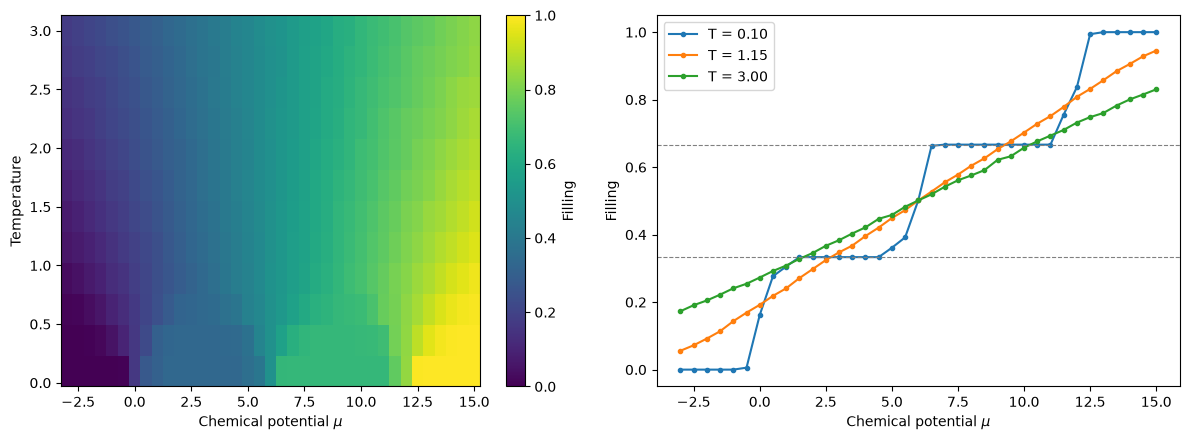

In [3]:
g = geometry.triangular_lattice()
g = supercell.turn_orthorhombic(g)
g = g.get_supercell(6) # periodic supercell with 72 sites

lg = latticegas.LatticeGas(g,filling=0.0)
lg.add_interaction(Jij=[1.]) # first-neighbor repulsion
mus = np.linspace(-3.,15.,37) # chemical potential
temps = np.linspace(3.,0.1,12) # from high to low temperature
fill = np.zeros((len(temps),len(mus)))
for j,mu in enumerate(mus):
    lg.mu[:] = -mu # onsite energy -mu favors occupation
    for i,T in enumerate(temps): # cool down at fixed chemical potential
        es,ns = lg.optimize_grand_canonical(temp=T,ntries=300*lg.nsites)
        fill[i,j] = np.mean(ns[len(ns)//2:])/lg.nsites # discard the equilibration

fig,axs = plt.subplots(1,2,figsize=(12,4.5))
im = axs[0].pcolormesh(mus,temps,fill,shading="nearest",cmap="viridis")
plt.colorbar(im,ax=axs[0],label="Filling")
axs[0].set_xlabel("Chemical potential $\\mu$") ; axs[0].set_ylabel("Temperature")
for i in [11,7,0]:
    axs[1].plot(mus,fill[i],marker="o",ms=3,label=f"T = {temps[i]:.2f}")
for f in [1./3.,2./3.]: axs[1].axhline(f,c="gray",ls="--",lw=0.8)
axs[1].set_xlabel("Chemical potential $\\mu$") ; axs[1].set_ylabel("Filling") ; axs[1].legend()
plt.tight_layout()
plt.show()